In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
from matplotlib import rcParams
from statannotations.Annotator import Annotator

In [2]:
from general_functions import remove_small_clusters, clinical_enrichment, calculate_stability_metrics, consensus_matrix

In [3]:
RANDOM_STATE = 42
n_clusters = 2

# Final clusters

To obtain the final clusters, the combination of methylation and copy number (CNA) was used, and the algorithm NEMO applied. First, let's look at the stability of the clusters after _n_ runs:

In [4]:
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [5]:
import warnings
warnings.filterwarnings("ignore")
final_clusters = pd.read_csv('../results/cluster_analysis/benchmarking_files/final_clusters_file.csv',
                             dtype={'view_combination': str},
                             converters={'y_pred': eval, 'y_pred_idx': eval, 
                                         'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
clinical_data_file = pd.read_csv('../data/TCGA/omics_data/raw/cancer_data_PAAD_clinical_data.tsv', sep='\t', header=0)

First, let's check if there are any very small clusters formed.

In [6]:
valid_results, outlier_results, df_top_outliers = remove_small_clusters(final_clusters, 10, verbose=True)

Top 10 outlier patients: []


In this case, there are no patients grouped into a small cluster.

In [7]:
clin_results = clinical_enrichment(final_clusters, clinical_data_file)

In [8]:
clin_results['pvalue_logrank'].mean()

0.22715949536737734

In [9]:
stability_dict = {}
for i in np.arange(10):
    subset = final_clusters.iloc[:(2**(i+1))]
    summarised_results = calculate_stability_metrics(subset, random_state=RANDOM_STATE, progress_bar=True)
    stability_dict[i] = summarised_results['AMI'].iloc[0]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [31:30<00:00, 1890.74s/it]


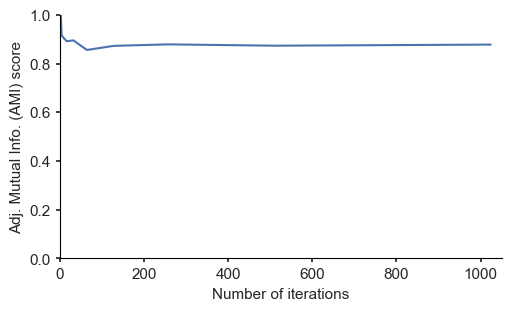

In [11]:
stability_df = pd.DataFrame(stability_dict.items(), columns=['log2(n_runs)', 'AMI'])
stability_df['n_runs'] = 2 ** (stability_df['log2(n_runs)'] + 1)
plt.figure(figsize=(5, 3))
sns.lineplot(x=stability_df['n_runs'], y=stability_df['AMI'])
plt.ylabel('Adj. Mutual Info. (AMI) score')
plt.ylim(0, 1)
plt.xlim(0, 1050)
plt.xlabel('Number of iterations')
plt.xscale('linear')
# plt.savefig('FIGURES/final_clusters/stability_finalclusters.svg', bbox_inches='tight')
plt.show()

In [13]:
consensus_matrix = consensus_matrix(final_clusters)

In [15]:
consensus_matrix.to_csv("consensus_matrix.csv")

In [7]:
consensus_matrix = pd.read_csv("consensus_matrix.csv", index_col=0)
consensus_matrix

,TCGA-FZ-5926,TCGA-FB-AAQ1,TCGA-IB-A5SO,TCGA-HZ-8003,TCGA-US-A77G,TCGA-XD-AAUL,TCGA-XN-A8T3,TCGA-IB-7887,TCGA-HZ-8002,TCGA-FZ-5924,...,TCGA-HZ-A8P1,TCGA-IB-AAUS,TCGA-2J-AABE,TCGA-FB-AAPP,TCGA-HZ-A4BH,TCGA-IB-8126,TCGA-FZ-5920,TCGA-PZ-A5RE,TCGA-HZ-7926,TCGA-IB-A5SP
TCGA-FZ-5926,0.000000,0.949922,0.778638,0.051005,0.948328,0.959627,0.963190,0.959752,0.047690,0.951863,...,0.953030,0.044207,0.950693,0.950558,0.952087,0.975867,0.950479,0.957640,0.948328,0.955453
TCGA-FB-AAQ1,0.949922,0.000000,0.711599,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.933333,1.000000,1.000000,1.000000,1.000000
TCGA-IB-A5SO,0.778638,0.711599,0.000000,0.262121,0.722802,0.748466,0.709145,0.727829,0.274074,0.717988,...,0.719697,0.280728,0.710606,0.707472,0.721362,0.787879,0.721959,0.723565,0.751534,0.718224
TCGA-HZ-8003,0.051005,0.000000,0.262121,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.071953,0.000000,0.000000,0.000000,0.000000
TCGA-US-A77G,0.948328,1.000000,0.722802,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.932945,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-IB-8126,0.975867,0.933333,0.787879,0.071953,0.932945,0.944444,0.940751,0.938053,0.069666,0.935007,...,0.938953,0.060958,0.930781,0.931402,0.941263,0.000000,0.929664,0.939042,0.930029,0.938865
TCGA-FZ-5920,0.950479,1.000000,0.721959,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.929664,0.000000,1.000000,1.000000,1.000000
TCGA-PZ-A5RE,0.957640,1.000000,0.723565,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.939042,1.000000,0.000000,1.000000,1.000000
TCGA-HZ-7926,0.948328,1.000000,0.751534,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.930029,1.000000,1.000000,0.000000,1.000000


In [8]:
# Applying k-means clustering to consensus matrix
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE).fit(consensus_matrix)
kmeans_df = pd.DataFrame({
    'Patient ID': consensus_matrix.index,
    'Cluster': kmeans.labels_})
kmeans_clusters = {}
for cluster in range(n_clusters):
    kmeans_clusters[f'Cluster_{cluster}'] = kmeans_df[kmeans_df['Cluster'] == cluster]['Patient ID'].tolist()

  File "C:\Users\Carlos Paja Suarez\anaconda3\envs\imoc-pdac\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\Carlos Paja Suarez\anaconda3\envs\imoc-pdac\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Carlos Paja Suarez\anaconda3\envs\imoc-pdac\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Carlos Paja Suarez\anaconda3\envs\imoc-pdac\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


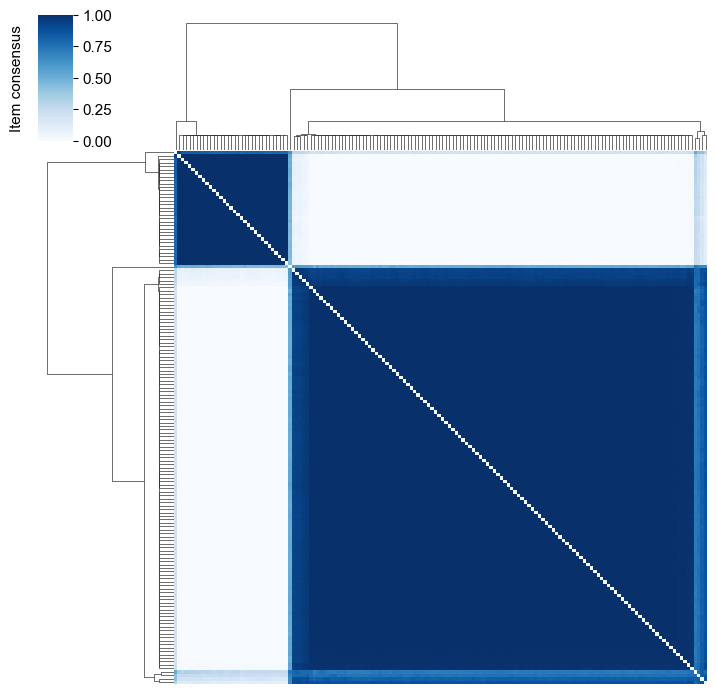

In [10]:
plt.rcParams.update(plt.rcParamsDefault)
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica']})
# Applying hierarchical clustering to consensus matrix
cm = sns.clustermap(consensus_matrix, cmap='Blues', yticklabels=False, xticklabels=False, figsize=(7,7))
cbar = cm.cax
cbar.set_ylabel("Item consensus", rotation=90, labelpad=10)
cbar.yaxis.set_label_position('left')
linkage_matrix = cm.dendrogram_row.linkage
cluster_assignments = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
# plt.savefig('FIGURES/final_clusters/consensus_final_clusters.svg', bbox_inches='tight')
# plt.savefig('FIGURES/final_clusters/consensus_final_clusters.png', bbox_inches='tight')
plt.show()

patient_ids = consensus_matrix.index
hierarchical_clusters = {}
for cluster in range(1, n_clusters + 1):
    hierarchical_clusters[f'Cluster_{cluster-1}'] = [patient_ids[i] for i, assignment in enumerate(cluster_assignments) if assignment == cluster]

In [11]:
# Function to compare hierarchical clusters with K-means clusters
hierarchical_sets = {key: set(values) for key, values in hierarchical_clusters.items()}
kmeans_sets = {key: set(values) for key,values in kmeans_clusters.items()}
for h_key, h_set in hierarchical_sets.items():
    match_found = False
    for k_key, k_set in kmeans_sets.items():
        if h_set == k_set:
            print(f"Hierarchical {h_key} matches K-means {k_key}")
            match_found = True
            break
    if not match_found:
        print(f"Hierarchical {h_key} does not match any K-means cluster")

Hierarchical Cluster_0 matches K-means Cluster_1
Hierarchical Cluster_1 matches K-means Cluster_0


In [ ]:
# Convert to .csv file for easier analysis later
pd.DataFrame.from_dict(hierarchical_clusters, orient='index').to_csv('../data/patient_clusters.csv')

In [12]:
# Item consensus (only for two clusters)
def get_item_consensus(consensus_matrix: pd.DataFrame, ref_cluster_num: int):
    ref_cluster = hierarchical_clusters[f"Cluster_{ref_cluster_num}"]
    other_cluster = 0 if ref_cluster_num == 1 else 1
    item_consensus = {}
    for patient in consensus_matrix.columns:
        if patient in ref_cluster:
            cluster_matrix = consensus_matrix.loc[consensus_matrix.index.isin(ref_cluster), consensus_matrix.columns.isin(ref_cluster)]
            ref_cluster_avg = cluster_matrix[patient].mean()
            other_cluster_avg = 1 - ref_cluster_avg
        else:
            cluster_matrix = consensus_matrix.loc[~consensus_matrix.index.isin(ref_cluster), ~consensus_matrix.columns.isin(ref_cluster)]
            other_cluster_avg = cluster_matrix[patient].mean()
            ref_cluster_avg = 1 - other_cluster_avg
        item_consensus[patient] = {f"cluster{ref_cluster_num}": ref_cluster_avg, f"cluster{other_cluster}": other_cluster_avg}
    return item_consensus

In [13]:
item_consensus = get_item_consensus(consensus_matrix, 1)
sorted_dict = dict(sorted(item_consensus.items(), key=lambda item: item[1]['cluster0'], reverse=True))

In [ ]:
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

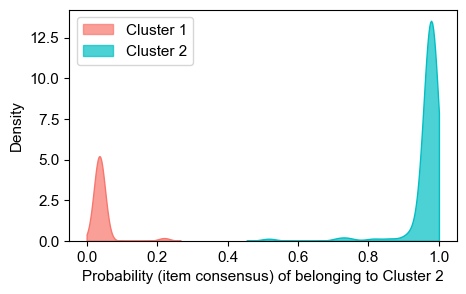

In [18]:
cluster_0_patients = hierarchical_clusters['Cluster_0']
cluster_1_patients = hierarchical_clusters['Cluster_1']

probabilities = []
groups = []
patients = []
for patient, probs in sorted_dict.items():
    # Use probability of belonging to cluster1, so that patients from cluster 0 have a probability of 0
    patients.append(patient)
    if patient in cluster_0_patients:
        probabilities.append(probs['cluster1'])  
        groups.append('Cluster 0')
    elif patient in cluster_1_patients:
        probabilities.append(probs['cluster1'])
        groups.append('Cluster 1')

df = pd.DataFrame({"PatientID":patients, 'Probability': probabilities, 'Cluster': groups})
plt.figure(figsize=(5, 3))
palette = ["#F8766D", "#00BFC4"]
sns.kdeplot(data=df, x="Probability", palette=palette, hue="Cluster", 
            multiple="layer", fill=True, alpha=0.7, clip=(0, 1))
plt.legend(labels=['Cluster 1', 'Cluster 2'], loc='upper left', 
           handles=[plt.Rectangle((0, 0), 1, 1, color=palette[0], alpha=0.7), 
                    plt.Rectangle((0, 0), 1, 1, color=palette[1], alpha=0.7)])
plt.xlabel("Probability (item consensus) of belonging to Cluster 2")
plt.ylabel("Density")
# plt.savefig('FIGURES/final_clusters/item_consensus.svg', bbox_inches='tight')
plt.show()

In [20]:
df.to_csv("item_consensus.csv")

### Comparing methylation and copy number data, based on cluster assignments

In [21]:
hierarchical_cluster0 = hierarchical_clusters['Cluster_0']
hierarchical_cluster1 = hierarchical_clusters['Cluster_1']

In [61]:
# Get data from both methylation and CNA
CNA_file = pd.read_csv('../data/TCGA/omics_data/preprocessed/all_patients/TCGA_PDAC_all_CNA.csv', index_col=0)
CNA_file['Cluster'] = None
for cluster_num, patients in hierarchical_clusters.items():
    cluster_label = int(cluster_num.split('_')[-1])
    CNA_file.loc[CNA_file.index.isin(patients), 'Cluster'] = cluster_label
CNA_data = CNA_file.sort_values(by='Cluster')

methylation_file = pd.read_csv('../data/TCGA/omics_data/preprocessed/all_patients/TCGA_PDAC_all_Methylation.csv', index_col=0)
methylation_file['Cluster'] = None
for cluster_num, patients in hierarchical_clusters.items():
    cluster_label = int(cluster_num.split('_')[-1])
    methylation_file.loc[methylation_file.index.isin(patients), 'Cluster'] = cluster_label
methylation_data = methylation_file.sort_values(by='Cluster')

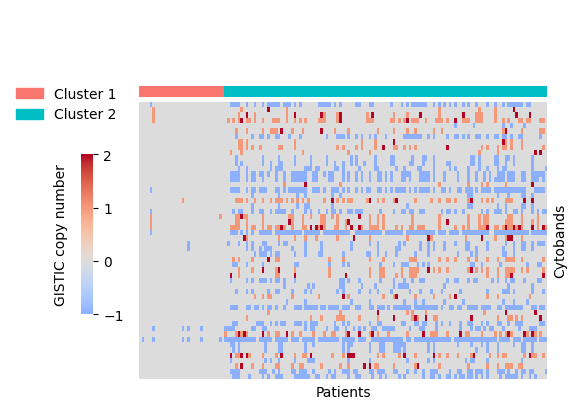

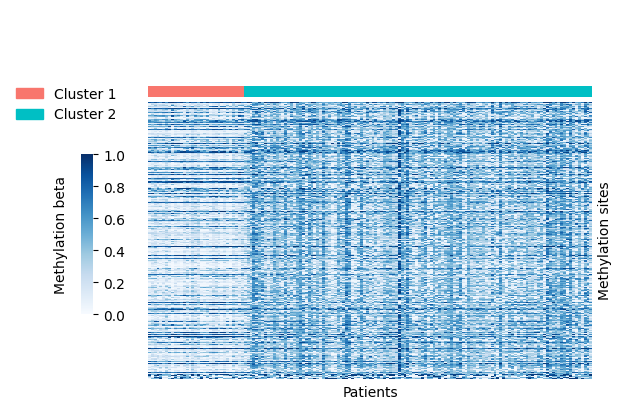

In [65]:
plt.rcParams.update(plt.rcParamsDefault)
import matplotlib.patches as mpatches
palette = ["#F8766D", "#00BFC4"]

# Plot heatmaps
CNA_data.dropna(inplace=True)
methylation_data.dropna(inplace=True)
clusters_CNA = CNA_data['Cluster'].unique()
color_mapping_CNA = dict(zip(clusters_CNA, palette))
cluster_colors_CNA = CNA_data['Cluster'].map(color_mapping_CNA)
cm_cna = sns.clustermap(data=CNA_data.drop(columns=['Cluster']).T, col_colors=cluster_colors_CNA, cmap='coolwarm', col_cluster=False, 
                        row_cluster=False, figsize=(6,4), center=0, xticklabels=False, yticklabels=False, cbar_pos=(0.1, 0.2, 0.02, 0.4))
cbar = cm_cna.cax
cbar.set_ylabel("GISTIC copy number", rotation=90, labelpad=10)
cbar.yaxis.set_label_position('left')
cm_cna.ax_col_colors.set_yticks([])
plt.legend(labels=['Cluster 1', 'Cluster 2'], frameon=False, bbox_to_anchor=[4, 1.5],
           handles=[plt.Rectangle((0, 0), 1, 1, color=palette[0]), 
                    plt.Rectangle((0, 0), 1, 1, color=palette[1])])
cm_cna.ax_heatmap.set_xlabel('Patients')
cm_cna.ax_heatmap.set_ylabel('Cytobands')
# plt.savefig('FIGURES/final_clusters/cna_heatmap.png', bbox_inches='tight')
plt.show()

clusters_methylation = methylation_data['Cluster'].unique()
color_mapping_methylation = dict(zip(clusters_methylation, palette))
cluster_colors_methylation = methylation_data['Cluster'].map(color_mapping_methylation)
cm_methyl = sns.clustermap(data=methylation_data.drop(columns=['Cluster']).T, col_colors=cluster_colors_methylation.rename(" "), cmap='Blues', col_cluster=False, 
                          row_cluster=False, figsize=(6, 4), xticklabels=False, yticklabels=False, cbar_pos=(0.1, 0.2, 0.02, 0.4), vmin=0, vmax=1)
cbar = cm_methyl.cax
cbar.set_ylabel("Methylation beta", rotation=90, labelpad=10)
cbar.yaxis.set_label_position('left')
cm_methyl.ax_col_colors.set_yticks([])
plt.legend(labels=['Cluster 1', 'Cluster 2'], frameon=False, bbox_to_anchor=[4, 1.5],
           handles=[plt.Rectangle((0, 0), 1, 1, color=palette[0]), 
                    plt.Rectangle((0, 0), 1, 1, color=palette[1])])
cm_methyl.ax_heatmap.set_xlabel('Patients')
cm_methyl.ax_heatmap.set_ylabel('Methylation sites')
# plt.savefig('FIGURES/final_clusters/methyl_heatmap.png', bbox_inches='tight')
plt.show()

In [66]:
rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 12,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

0 vs. 1: p = 2.64e-15
0 vs. 1: p = 9.84e-18


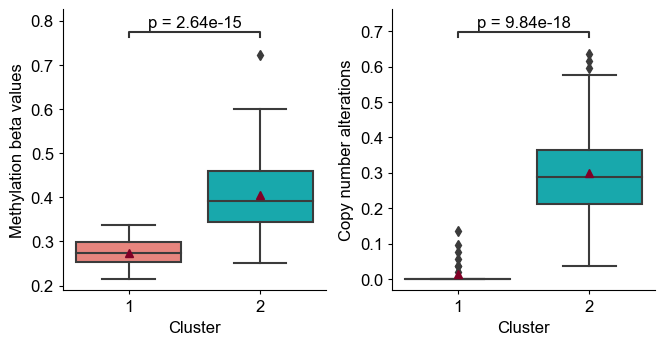

In [67]:
palette = ["#F8766D", "#00BFC4"]
from scipy.stats import mannwhitneyu
methyl_means = methylation_data.drop(columns='Cluster').mean(numeric_only=True, axis=1)
methyl_means = pd.DataFrame({"Methylation": methyl_means, "Cluster": methylation_data["Cluster"].values})

cna_means = CNA_data.abs().drop(columns='Cluster').mean(numeric_only=True, axis=1)
cna_means = pd.DataFrame({"CNA": cna_means, "Cluster": CNA_data["Cluster"].values})

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
pairs = [(0, 1)]
sns.boxplot(data=methyl_means, x='Cluster', y='Methylation', showmeans=True, ax=ax[0], palette=palette, meanprops={"markerfacecolor": "#800026","markeredgecolor": "#800026"})
ax[0].set_ylabel('Methylation beta values')
ax[0].set_xticklabels([1, 2])
mgroup0 = methyl_means.loc[methyl_means["Cluster"] == 0, "Methylation"]
mgroup1 = methyl_means.loc[methyl_means["Cluster"] == 1, "Methylation"]
mstat, mp_value = mannwhitneyu(mgroup0, mgroup1)
mannotator = Annotator(ax[0], pairs, data=methyl_means, x='Cluster', y='Methylation')
mannotator.configure(test=None, text_format="simple", loc="inside")
mannotator.set_custom_annotations([f"p = {mp_value:.2e}"])
mannotator.annotate()

sns.boxplot(data=cna_means, x='Cluster', y='CNA', showmeans=True, ax=ax[1], palette=palette, meanprops={"markerfacecolor": "#800026","markeredgecolor": "#800026"})
ax[1].set_ylabel('Copy number alterations')
ax[1].set_xticklabels([1, 2])
cnagroup0 = cna_means.loc[cna_means["Cluster"] == 0, "CNA"]
cnagroup1 = cna_means.loc[cna_means["Cluster"] == 1, "CNA"]
cnastat, cnap_value = mannwhitneyu(cnagroup0, cnagroup1)
cnaannotator = Annotator(ax[1], pairs, data=cna_means, x='Cluster', y='CNA')
cnaannotator.configure(test=None, text_format="simple", loc="inside")
cnaannotator.set_custom_annotations([f"p = {cnap_value:.2e}"])
cnaannotator.annotate()

plt.tight_layout()
# plt.savefig('FIGURES/final_clusters/methyl_cna_comparison.svg', bbox_inches='tight')
plt.show()